# Spark vs. Modes

How do the sparkles project onto the controlling basis set? What modes do we exepect to be affected by the sparkles? Do we think the measurement of optical gain will be afected by the sparkle themselves? If so where in the mode count do we expect this to happen?

In [1]:
from astropy.io import fits
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# first, load in the calibration basis set in a way that works for proejction
# so probably a basis set that has [N, 120, 120]

#CWFS

cacao_dir = "/opt/MagAOX/cacao/tweeter-vispyr/tweeter-vispyr-calibs/default"
mode_fits_f = cacao_dir + "/CMmodesWFS.fits"
mode_fits = fits.open(mode_fits_f)
mode_data = mode_fits[0].data

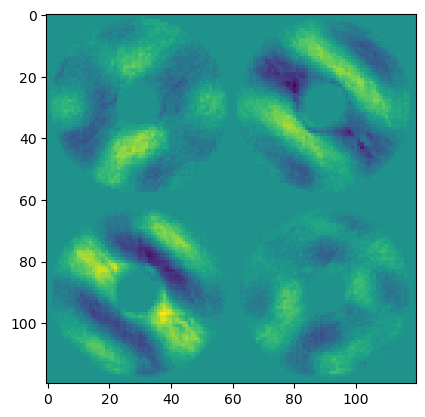

In [5]:
plt.imshow(mode_data[20])

In [6]:
# Now pull a PCA modal basis 
spark_calib_dir = "/opt/MagAOX/calib/spark-PCA"
ex_calib = "sep16_ang45_amp0.030_freq2000/"

ex_PCA_modes = fits.open(spark_calib_dir + "/" + ex_calib + "ref_pca.fits")[0].data.reshape(120,120,3)


In [7]:
# projects
projection = mode_data.reshape(mode_data.shape[0],120*120) @ ex_PCA_modes.reshape(120*120,3)

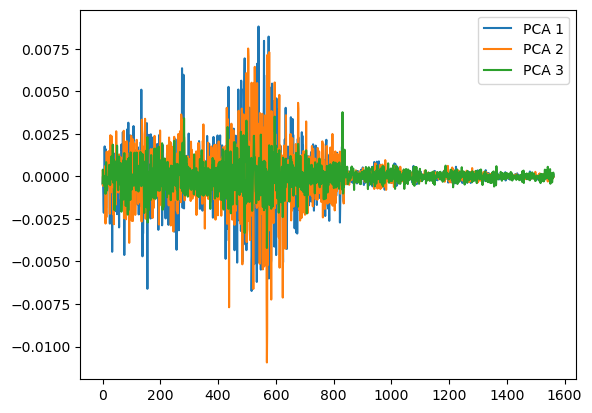

In [8]:
# example of a projection 
plt.plot(projection[:,0], label="PCA 1")
plt.plot(projection[:,1], label="PCA 2")
plt.plot(projection[:,2], label="PCA 3")
plt.legend()
plt.show()

### loop through all the PCA modal basis

See what the average is, subtract that, see the differentials per mode

In [9]:
from sparkles.calibration_iter import project_all_calibrations_to_modal_basis

cacao_dir = "/opt/MagAOX/cacao/tweeter-vispyr/tweeter-vispyr-calibs/default"
mode_fits_f = cacao_dir + "/CMmodesWFS.fits"
mode_fits = fits.open(mode_fits_f)
mode_basis = mode_fits[0].data

proj_list, param_map = project_all_calibrations_to_modal_basis(
    "/home/eden/data/spark_calib",
    mode_basis.reshape(mode_basis.shape[0], 120*120),
)

/tmp/ipykernel_3362154/313783481.py:8: UserWarning: Skipping sep22_ang60_amp0.030_freq2000: missing ref_pca.fits
  proj_list, param_map = project_all_calibrations_to_modal_basis(


In [10]:
proj_list = np.array(proj_list)

In [11]:
proj_list.shape

(247, 1563, 3)

In [12]:
avg_node_resp = np.median(proj_list, axis=(0,2))

In [13]:
param_map[103]

{'calib_folder': 'sep15_ang30_amp0.030_freq2000',
 'calib_path': '/home/eden/data/spark_calib/sep15_ang30_amp0.030_freq2000',
 'spark_sep': 15.0,
 'spark_ang': 30.0,
 'spark_amp': 0.03,
 'wfs_hz': 2000.0,
 'n_modal_modes': 1563,
 'n_calibration_modes': 3}

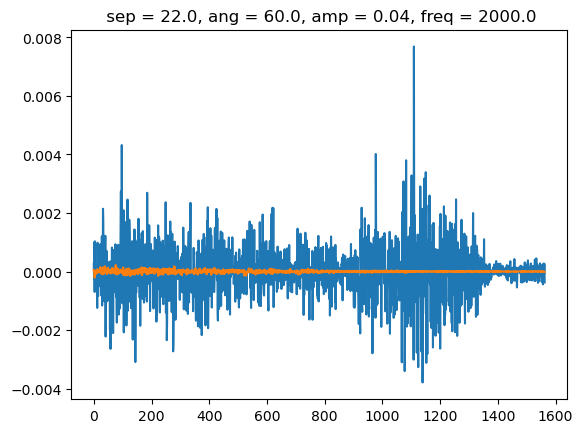

In [16]:
n = 240
n_dict = param_map[n]
plt.title(f" sep = {n_dict['spark_sep']}, ang = {n_dict['spark_ang']}, amp = {n_dict['spark_amp']}, freq = {n_dict['wfs_hz']}")

plt.plot(proj_list[n,:,0])
plt.plot(avg_node_resp)

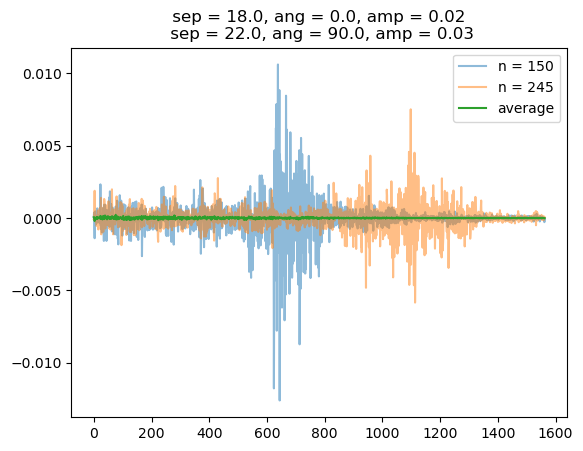

In [18]:
n1 = 150
n2 = 245
n1_dict = param_map[n1]
n2_dict = param_map[n2]
plt.title(f" sep = {n1_dict['spark_sep']}, ang = {n1_dict['spark_ang']}, amp = {n1_dict['spark_amp']} \n sep = {n2_dict['spark_sep']}, ang = {n2_dict['spark_ang']}, amp = {n2_dict['spark_amp']}")

plt.plot(proj_list[n1,:,0], label=f"n = {n1}", alpha=0.5)
plt.plot(proj_list[n2,:,0], label=f"n = {n2}", alpha=0.5)
plt.plot(avg_node_resp, label="average")
plt.legend()
plt.show()

## Compare response



In [19]:
import sparkles.calibration_iter as cbi


In [35]:
import pandas as pd


def summarize_pca_mode1_by_angle(
    proj_list,
    param_map,
    spark_sep,
    pca_mode_idx=0,
):
    """
    Build a summary table for one separation.

    proj_list shape is expected to be (n_calibs, n_modal_modes, n_pca_modes).
    """
    rows = []
    for i, proj in enumerate(proj_list):
        if i not in param_map:
            continue

        meta = param_map[i]
        if not np.isclose(meta["spark_sep"], spark_sep):
            continue

        mode_vec = proj[:, pca_mode_idx]
        rows.append(
            {
                "idx": i,
                "spark_sep": meta["spark_sep"],
                "spark_ang": meta["spark_ang"],
                "spark_amp": meta["spark_amp"],
                "wfs_hz": meta["wfs_hz"],
                "mode1_resp": mode_vec,
            }
        )

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["spark_ang", "spark_amp"]).reset_index(drop=True)
    return df

## Significant mode deviations heatmap

This plot highlights which basis modes deviate strongly from the global average response using z-scores.
- rows: angle (for a fixed separation)
- columns: basis mode number
- color: z-score of deviation from average

In [33]:
def plot_significant_mode_deviation_heatmap(
    df_sep,
    z_thresh=2.5,
    eps=1e-12,
    cmap="RdBu_r",
):
    """
    Heatmap of per-angle mode deviations from global average.

    Parameters
    ----------
    df_sep : DataFrame
        Output of summarize_pca_mode1_by_angle for one separation.
    z_thresh : float
        Absolute z-score threshold for significance mask overlay.
    """
    if df_sep.empty:
        raise ValueError("Input DataFrame is empty.")

    # Average each angle across all amplitudes/runs.
    grouped = (
        df_sep.groupby("spark_ang", sort=True)["mode1_resp"]
        .apply(lambda v: np.mean(np.stack(v.values, axis=0), axis=0))
        .reset_index()
    )

    angle_vals = grouped["spark_ang"].to_numpy()
    mat = np.stack(grouped["mode1_resp"].values, axis=0)  # (n_angles, n_modes)

    # Global baseline and mode-wise spread.
    mode_mean = np.mean(mat, axis=0, keepdims=True)
    mode_std = np.std(mat, axis=0, keepdims=True)
    z = (mat - mode_mean) / np.maximum(mode_std, eps)

    # Clip extreme values so colormap stays readable.
    vmax = np.nanpercentile(np.abs(z), 99)
    vmax = max(vmax, z_thresh)
    vmin = -vmax

    plt.figure(figsize=(14, 4.8))
    im = plt.imshow(z, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

    # Overlay significance mask points.
    sig = np.abs(z) >= z_thresh
    yy, xx = np.where(sig)
    if len(xx) > 0:
        plt.scatter(xx, yy, s=6, c="k", marker=".", alpha=0.55, label=f"|z| >= {z_thresh}")
        plt.legend(loc="upper right", fontsize=8)

    sep_val = float(df_sep["spark_sep"].iloc[0])
    plt.title(f"Significant basis-mode deviations by angle (sep={sep_val:.0f})")
    plt.xlabel("basis mode number")
    plt.ylabel("spark_ang")
    plt.yticks(np.arange(len(angle_vals)), [f"{a:.0f}" for a in angle_vals])
    cbar = plt.colorbar(im)
    cbar.set_label("z-score of mode response")
    plt.tight_layout()
    plt.show()

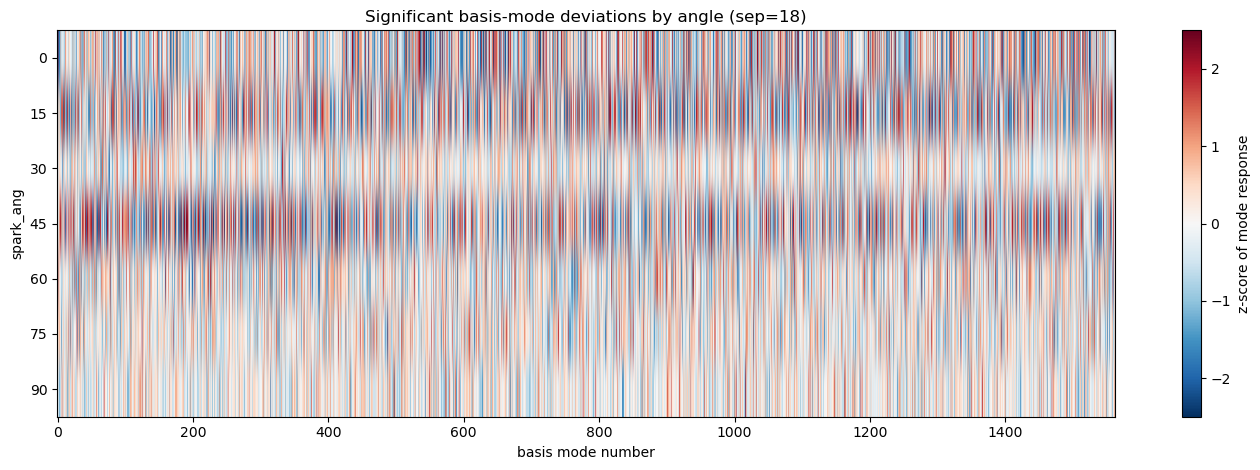

In [36]:
# Example usage
sep_to_plot = 18
mode1_df = summarize_pca_mode1_by_angle(
    proj_list,
    param_map,
    spark_sep=sep_to_plot,
    pca_mode_idx=0,
)
plot_significant_mode_deviation_heatmap(mode1_df, z_thresh=2.5)

## Summary by separation

Use this when you want to fix an angle and compare responses across `spark_sep`.

In [38]:
def summarize_pca_mode1_by_separation(
    proj_list,
    param_map,
    spark_ang,
    pca_mode_idx=0,
):
    """
    Build a summary table for one angle, grouped over separations.

    proj_list shape is expected to be (n_calibs, n_modal_modes, n_pca_modes).
    """
    rows = []
    for i, proj in enumerate(proj_list):
        if i not in param_map:
            continue

        meta = param_map[i]
        if not np.isclose(meta["spark_ang"], spark_ang):
            continue

        mode_vec = proj[:, pca_mode_idx]
        rows.append(
            {
                "idx": i,
                "spark_sep": meta["spark_sep"],
                "spark_ang": meta["spark_ang"],
                "spark_amp": meta["spark_amp"],
                "wfs_hz": meta["wfs_hz"],
                "mode1_resp": mode_vec,
            }
        )

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["spark_sep", "spark_amp"]).reset_index(drop=True)
    return df


def plot_significant_mode_deviation_heatmap_by_separation(
    df_ang,
    z_thresh=2.5,
    eps=1e-12,
    cmap="RdBu_r",
):
    """Heatmap of per-separation mode deviations from global average."""
    if df_ang.empty:
        raise ValueError("Input DataFrame is empty.")

    grouped = (
        df_ang.groupby("spark_sep", sort=True)["mode1_resp"]
        .apply(lambda v: np.mean(np.stack(v.values, axis=0), axis=0))
        .reset_index()
    )

    sep_vals = grouped["spark_sep"].to_numpy()
    mat = np.stack(grouped["mode1_resp"].values, axis=0)  # (n_sep, n_modes)

    mode_mean = np.mean(mat, axis=0, keepdims=True)
    mode_std = np.std(mat, axis=0, keepdims=True)
    z = (mat - mode_mean) / np.maximum(mode_std, eps)

    vmax = np.nanpercentile(np.abs(z), 99)
    vmax = max(vmax, z_thresh)
    vmin = -vmax

    plt.figure(figsize=(14, 4.8))
    im = plt.imshow(z, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

    sig = np.abs(z) >= z_thresh
    yy, xx = np.where(sig)
    if len(xx) > 0:
        plt.scatter(xx, yy, s=6, c="k", marker=".", alpha=0.55, label=f"|z| >= {z_thresh}")
        plt.legend(loc="upper right", fontsize=8)

    ang_val = float(df_ang["spark_ang"].iloc[0])
    plt.title(f"Significant basis-mode deviations by separation (ang={ang_val:.0f})")
    plt.xlabel("basis mode number")
    plt.ylabel("spark_sep")
    plt.yticks(np.arange(len(sep_vals)), [f"{s:.0f}" for s in sep_vals])
    cbar = plt.colorbar(im)
    cbar.set_label("z-score of mode response")
    plt.tight_layout()
    plt.show()

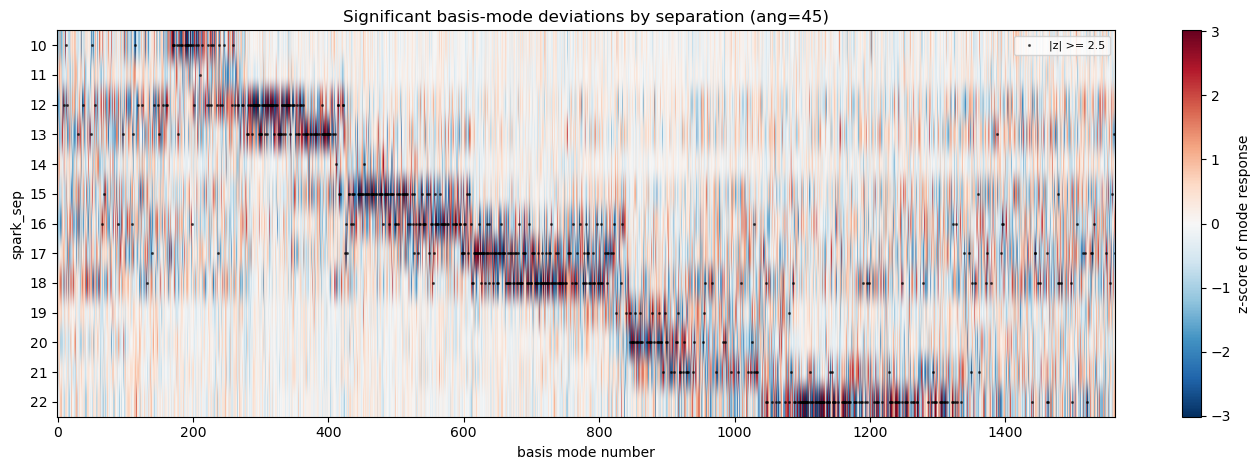

In [39]:
# Example usage (fixed angle, compare separations)
ang_to_plot = 45
mode1_sep_df = summarize_pca_mode1_by_separation(
    proj_list,
    param_map,
    spark_ang=ang_to_plot,
    pca_mode_idx=0,
)
plot_significant_mode_deviation_heatmap_by_separation(mode1_sep_df, z_thresh=2.5)

## Significant mode deviations heatmap

This plot highlights which basis modes deviate strongly from the global average response using z-scores.
- rows: angle (for a fixed separation)
- columns: basis mode number
- color: z-score of deviation from average

In [23]:
proj_sorted_grid = np.array(proj_sorted).reshape(1563, 247*3)

In [20]:
# for a given angle, find the average response to the first PCA mode, and see how the different angles for that separation compare

proj_sorted, map_sorted = cbi.sort_projection_params(
    proj_list,
    param_map,
    sep_order=[10, 12, 14, 16, 18, 20, 22],
    ang_order=[0, 15, 30, 45, 60, 75, 90],
    amp_order=[0.02, 0.03, 0.04],
)

In [27]:
grid_plot = np.abs(proj_sorted_grid.T)

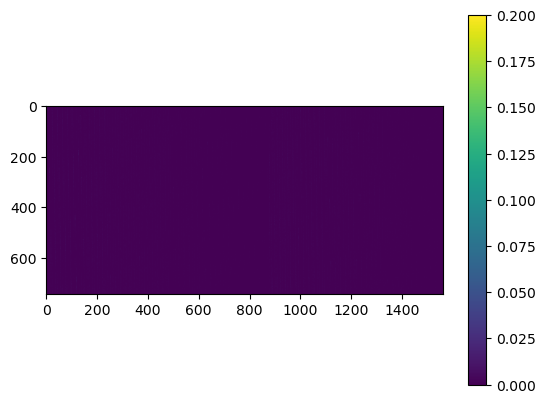

In [30]:
plt.imshow(grid_plot, vmax=0.2, vmin=0.0)

plt.colorbar()

